In [1]:
from pathlib import Path
import numpy as np
from feature import make_mfcc_extractor
from test_vectorized import (
    merge_consecutive_detections, run_detection_pipeline_new,
    load_all_template_features_new, load_all_thresholds_new,
    read_audio_chunk, plot_pr_curve, load_raven_selection_table,
    compute_pr_curve, compute_average_precision, match_detections,
    plot_detection_spectrograms, get_exclusion_intervals, get_exclusion_mask, compute_pr_curve_alpha, windows_to_calls
)


DATA_22 = Path(r"C:\Users\HP\Desktop\Skripsie data\22")
DATA_29 = Path(r"C:\Users\HP\Desktop\Skripsie data\29")
RESULTS_29 = DATA_29 / "template_selections"

RESULTS = Path(r"C:\Users\HP\Desktop\Skripsie data\Results")
THRESHOLDS = RESULTS / "Thresholds"

file_name = "5_Templates"
n_temps = 5
extractor = make_mfcc_extractor()

In [2]:
st_feats, mt_feats, bt_feats = load_all_template_features_new(
    results_dir=RESULTS_29,
    file_label="20230429_Templates",
    recording_label="20230429_102841",
    extractor=extractor,
    n_templates=n_temps,
    fs_new=1000,
)

Load thresholds

In [3]:
st_threshold, mt_threshold, bt_threshold = load_all_thresholds_new(
    results_dir=THRESHOLDS,
    file_label=file_name,          # matches what your calibration loop saved
    extractor=extractor,
)

print(f"Single Tone Threshold: {st_threshold}")
print(f"Multi Tone Threshold: {mt_threshold}")
print(f"Burst Tonal Threshold: {bt_threshold}")

Single Tone Threshold: 8.909031733068769
Multi Tone Threshold: 9.81759038614848
Burst Tonal Threshold: 11.553539245810656


Load 72 hour audio in 1 hour segments

In [4]:
ground_truth = load_raven_selection_table(DATA_22 / "2023-04-22T17-13-01_000_00070.txt")
td_intervals = get_exclusion_intervals(ground_truth, exclude_labels=("td",), pad=0.1)

all_detected_t, all_detected_labels, all_scores, all_labels_all, all_times_all, all_kth = run_detection_pipeline_new(
    audio_file=DATA_22 / "20230422_171301.wav",
    n_hours=72,
    st_feats=st_feats, mt_feats=mt_feats, bt_feats=bt_feats,
    st_threshold=st_threshold, mt_threshold=mt_threshold, bt_threshold=bt_threshold,
    exclude_intervals=td_intervals,
    extractor=extractor,
)

Processing hour 1 of 72: 1 / 47999 windows flagged as calls
Processing hour 2 of 72: 0 / 47999 windows flagged as calls
Processing hour 3 of 72: 1 / 47999 windows flagged as calls
Processing hour 4 of 72: 0 / 47999 windows flagged as calls
Processing hour 5 of 72: 0 / 47999 windows flagged as calls
Processing hour 6 of 72: 0 / 47999 windows flagged as calls
Processing hour 7 of 72: 0 / 47999 windows flagged as calls
Processing hour 8 of 72: 0 / 47999 windows flagged as calls
Processing hour 9 of 72: 0 / 47999 windows flagged as calls
Processing hour 10 of 72: 0 / 47999 windows flagged as calls
Processing hour 11 of 72: 0 / 47999 windows flagged as calls
Processing hour 12 of 72: 0 / 47999 windows flagged as calls
Processing hour 13 of 72: 0 / 47999 windows flagged as calls
Processing hour 14 of 72: 0 / 47999 windows flagged as calls
Processing hour 15 of 72: 1 / 47999 windows flagged as calls
Processing hour 16 of 72: 0 / 47999 windows flagged as calls
Processing hour 17 of 72: 1 / 479

Merge Consecutive detected windows

deployed: calls=520  P=0.287  R=0.091
sanity: 10393 10393
alpha=1: P=0.287  R=0.091   (should be close to the deployed line above)


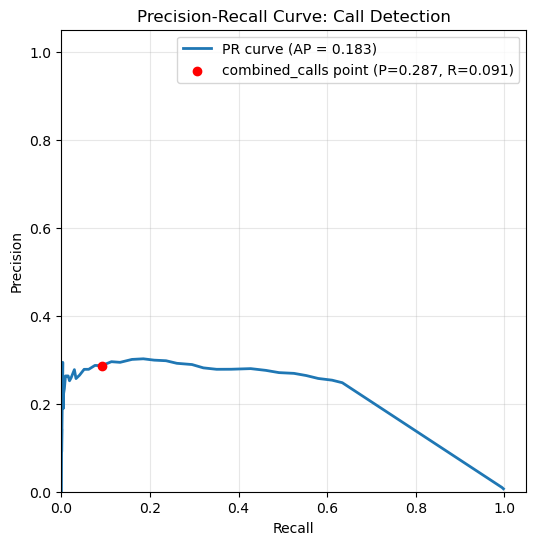

In [5]:
# 1. settings and ground truth first
MIN_WINDOWS = 4
MAX_WINDOWS = 14
merge_kw = dict(max_gap_windows=1, min_windows=MIN_WINDOWS, max_windows=MAX_WINDOWS)

ground_truth = load_raven_selection_table(DATA_22 / "2023-04-22T17-13-01_000_00070.txt")
ground_truth_eval = [g for g in ground_truth if g["label"] not in ("td",)]

# 2. deployed operating point (unchanged)
calls = merge_consecutive_detections(all_detected_t, all_detected_labels,
                                     step=0.075, window_len=0.15, **merge_kw)
tp, fp, fn, false_positive_detections, false_negative_gts = match_detections(
    calls, ground_truth_eval, require_label_match=False)
print(f"deployed: calls={len(calls)}  P={tp/(tp+fp):.3f}  R={tp/(tp+fn):.3f}")

# 3. alpha curve, using the same merge_kw
thr = (st_threshold, mt_threshold, bt_threshold)
best_ratio = (all_kth / np.array(thr)).min(axis=1)
print("sanity:", (best_ratio < 1).sum(), len(all_detected_t))   # should match

frac = len(all_detected_t) / len(all_times_all)
qs = np.quantile(best_ratio[np.isfinite(best_ratio)],
                 np.geomspace(1e-4, min(0.5, 5 * frac), 60))
alphas = np.unique(np.append(qs, [1.0, 2.0, 3.0]))

precision, recall, used, _ = compute_pr_curve_alpha(
    all_times_all, all_kth, thr, ground_truth_eval,
    step=0.075, window_len=0.15, alphas=alphas, **merge_kw)

p1, r1, _, _ = compute_pr_curve_alpha(
    all_times_all, all_kth, thr, ground_truth_eval,
    step=0.075, window_len=0.15, alphas=[1.0], **merge_kw)
print(f"alpha=1: P={p1[0]:.3f}  R={r1[0]:.3f}   (should be close to the deployed line above)")

ap = compute_average_precision(precision, recall)
plot_pr_curve(precision, recall, ap=ap, marked_point=(p1[0], r1[0]))

In [6]:
#combined_calls = merge_consecutive_detections(all_detected_t, all_detected_labels, step=0.075, window_len=0.15)

#print(f"Merged {len(all_detected_t)} raw window detections into {len(combined_calls)} calls")

PR curve / Ground truthing

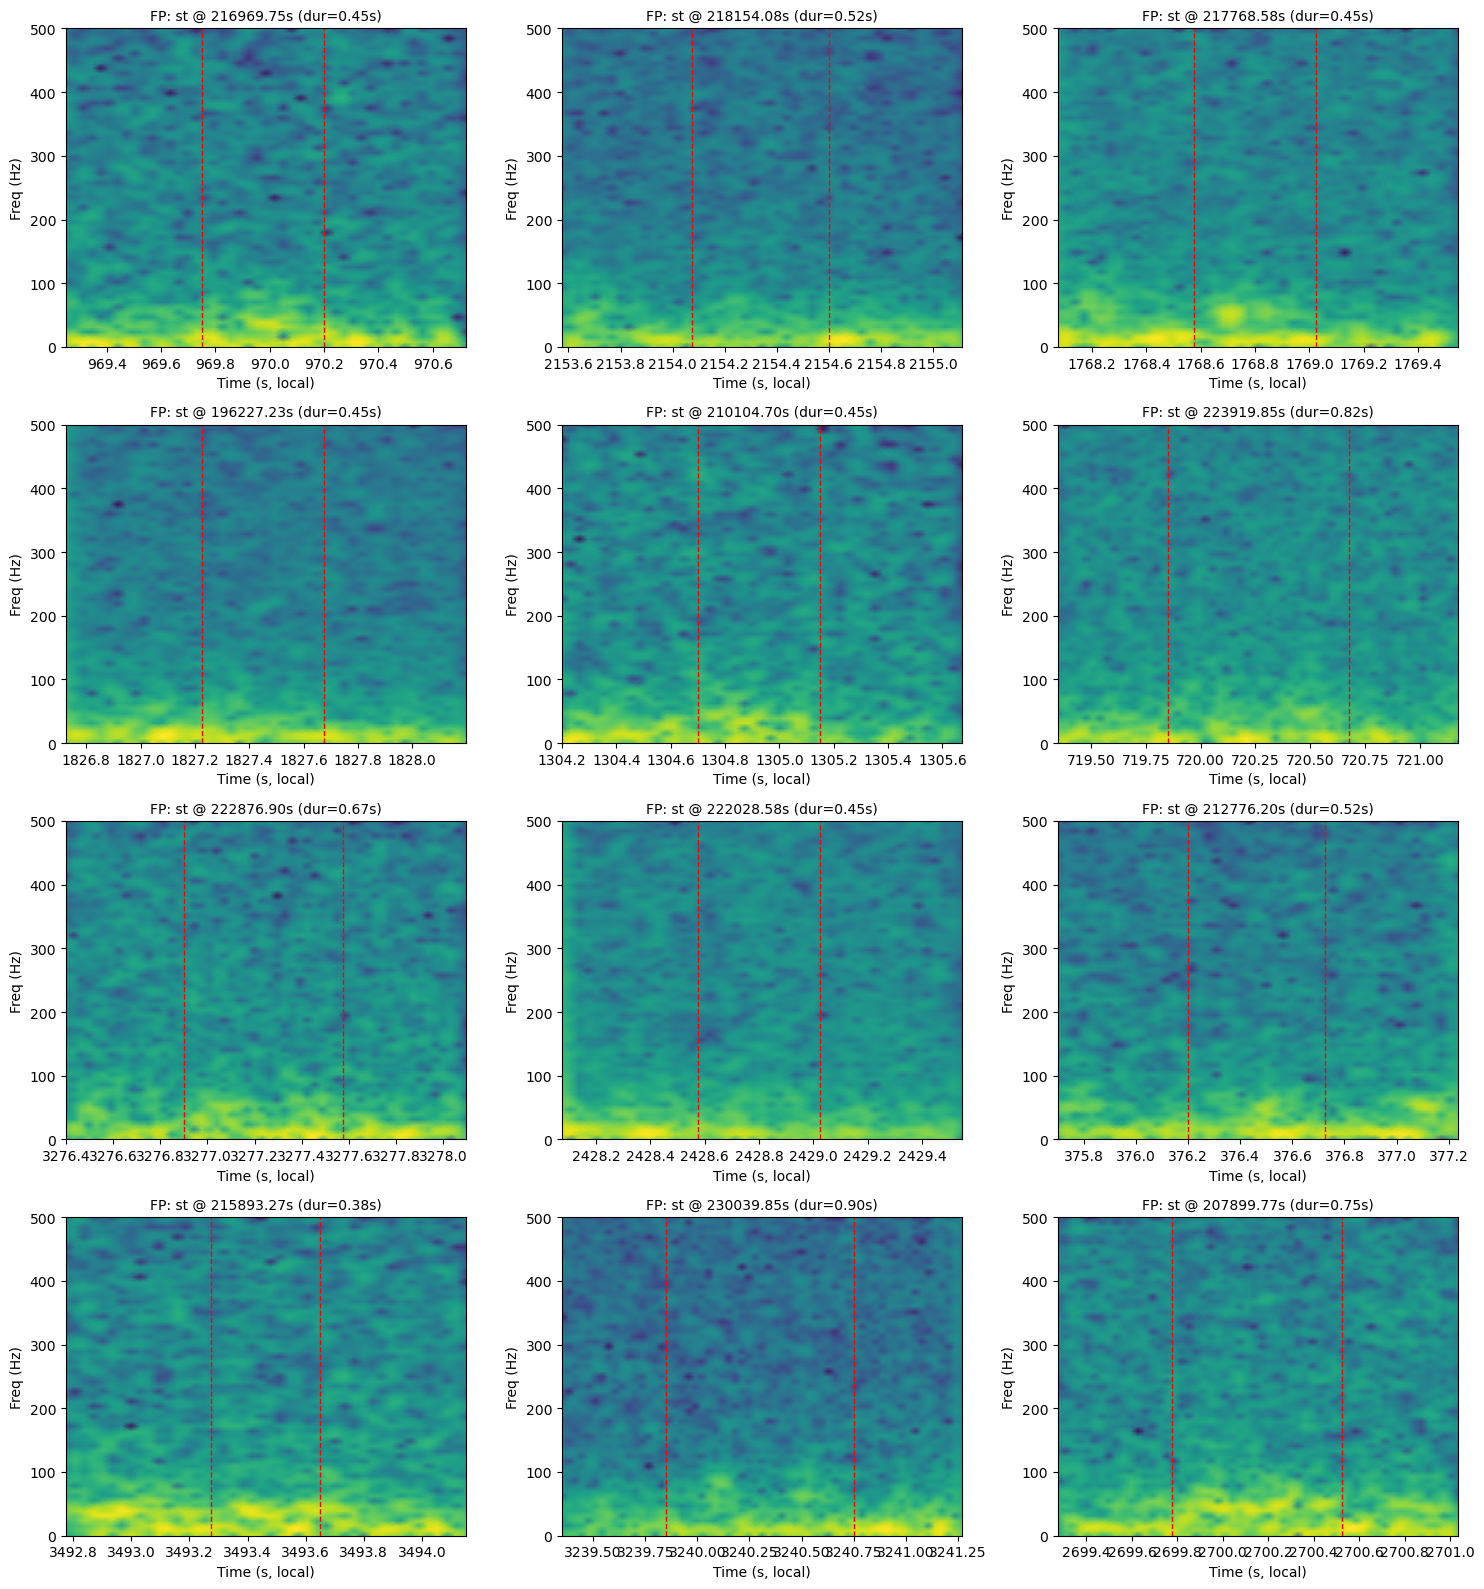

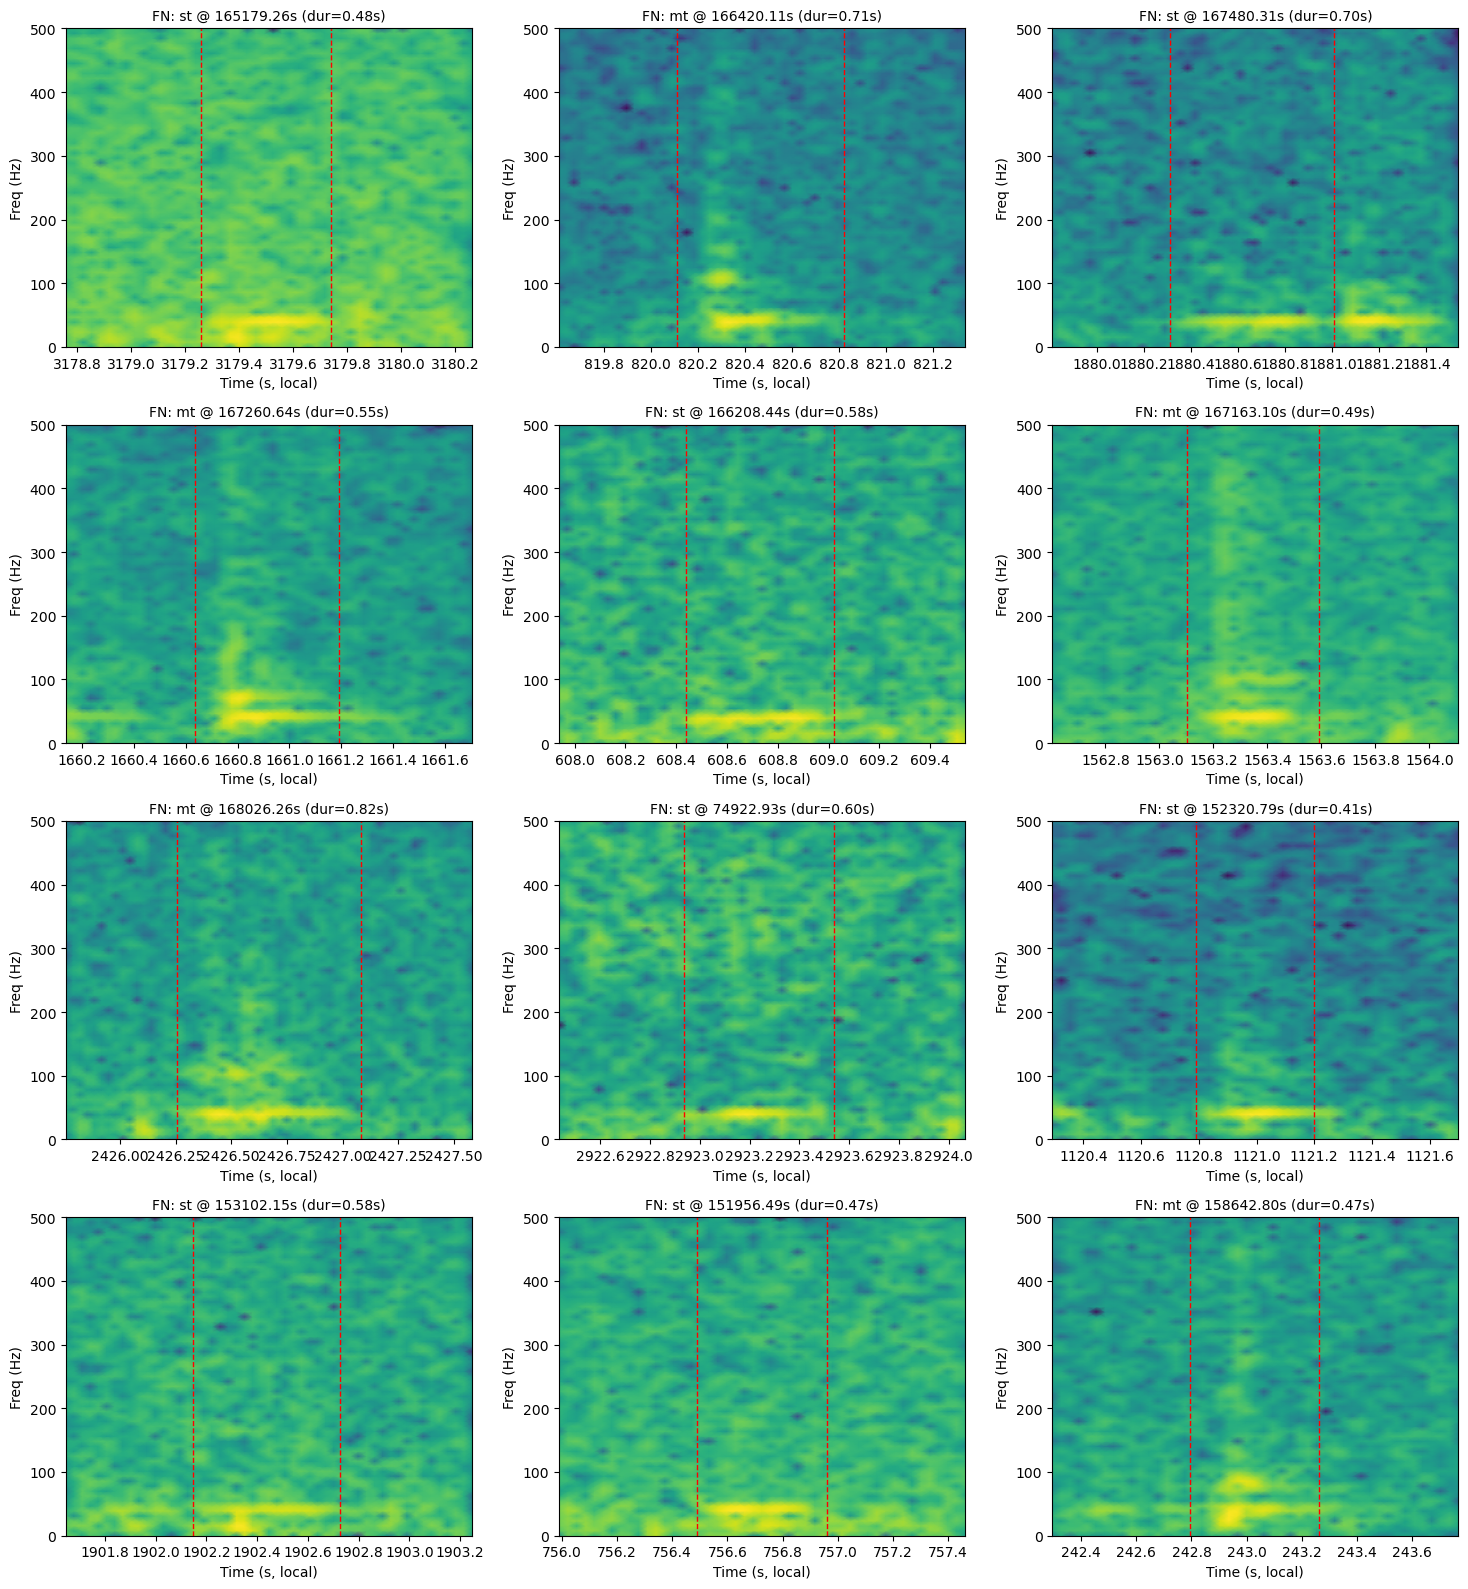

In [7]:
# plot a random sample of false positives
plot_detection_spectrograms(
    false_positive_detections,
    DATA_22 / "20230422_171301.wav",
    fs_new=1000,
    n_examples=12,
    title_prefix="FP"
)

# you can also inspect false negatives (missed calls) the same way
fn_as_tuples = [(g["start"], g["end"], g["label"]) for g in false_negative_gts]
plot_detection_spectrograms(
    fn_as_tuples,
    DATA_22 / "20230422_171301.wav",
    fs_new=1000,
    n_examples=12,
    title_prefix="FN"
)